In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv("/content/Position_Salaries.csv")
print(df.head())
print(df.info())
print(df.describe())

            Position  Level  Salary
0   Business Analyst      1   45000
1  Junior Consultant      2   50000
2  Senior Consultant      3   60000
3            Manager      4   80000
4    Country Manager      5  110000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Position  10 non-null     object
 1   Level     10 non-null     int64 
 2   Salary    10 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 372.0+ bytes
None
          Level          Salary
count  10.00000       10.000000
mean    5.50000   249500.000000
std     3.02765   299373.883668
min     1.00000    45000.000000
25%     3.25000    65000.000000
50%     5.50000   130000.000000
75%     7.75000   275000.000000
max    10.00000  1000000.000000


In [3]:
# Check missing values
print("Missing values:\n", df.isnull().sum())

# Fill missing numerical with mean, categorical with mode
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].mean())

# Remove duplicates
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after cleaning:", df.shape)

Missing values:
 Position    0
Level       0
Salary      0
dtype: int64
Shape after cleaning: (10, 3)


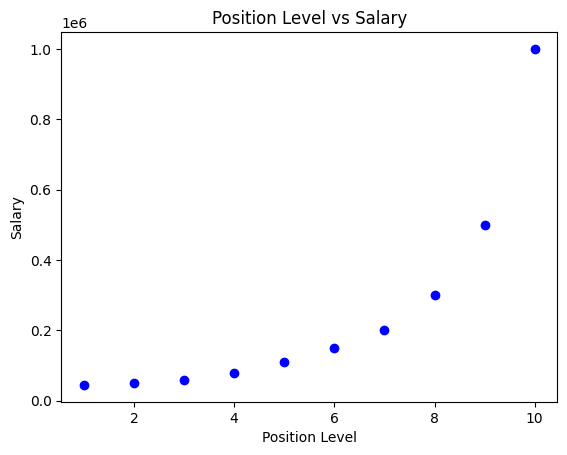

In [4]:
X = df.iloc[:, 1].values.reshape(-1, 1)  # Position Level
y = df.iloc[:, 2].values                  # Salary

plt.scatter(X, y, color="blue")
plt.title("Position Level vs Salary")
plt.xlabel("Position Level")
plt.ylabel("Salary")
plt.show()






# Extract the feature column (Position Level)
# df.iloc[:, 1]
#   :  -> select all rows
#   1  -> select the second column
#
# .values converts the Pandas Series into a NumPy array.
# Scikit-learn models work internally with NumPy arrays,
# so converting to .values ensures compatibility.
#
# Without .values:
#   type(df.iloc[:, 1]) -> pandas.Series
#
# With .values:
#   type(df.iloc[:, 1].values) -> numpy.ndarray
#
# reshape(-1, 1) converts the array from:
#   (n,)   -> one-dimensional array
# to
#   (n, 1) -> two-dimensional array with one feature column
# which is the format expected by scikit-learn for X.

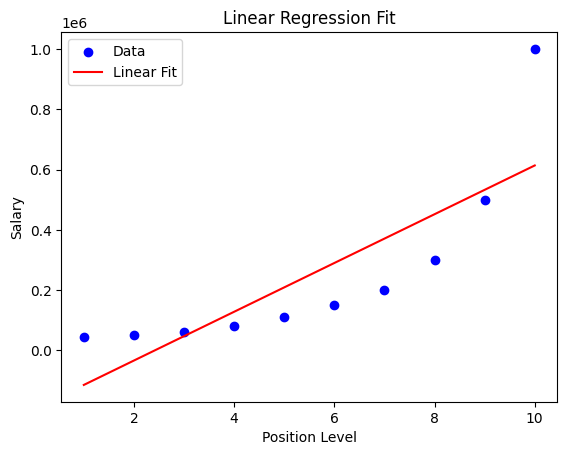

Linear R²  : 0.6690
Linear RMSE: 163388.74


In [5]:
lin_model = LinearRegression()
lin_model.fit(X, y)
y_lin_pred = lin_model.predict(X)

plt.scatter(X, y, color="blue", label="Data")
plt.plot(X, y_lin_pred, color="red", label="Linear Fit")
plt.title("Linear Regression Fit")
plt.xlabel("Position Level")
plt.ylabel("Salary")
plt.legend()
plt.show()

print(f"Linear R²  : {r2_score(y, y_lin_pred):.4f}")
print(f"Linear RMSE: {np.sqrt(mean_squared_error(y, y_lin_pred)):.2f}")

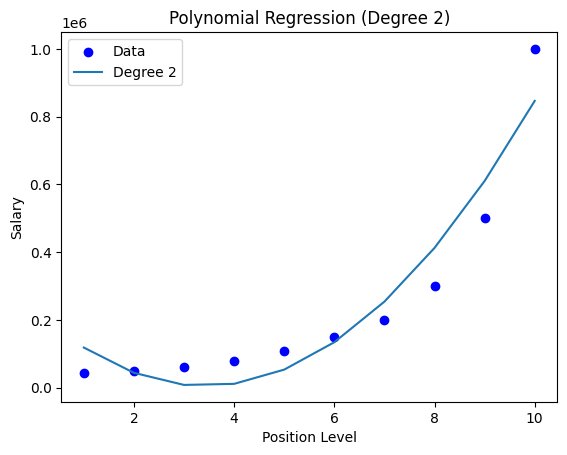

Degree 2 → R²: 0.9162, RMSE: 82212.12


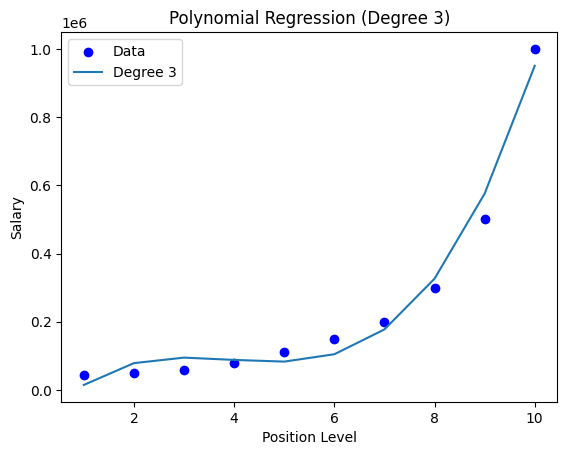

Degree 3 → R²: 0.9812, RMSE: 38931.50


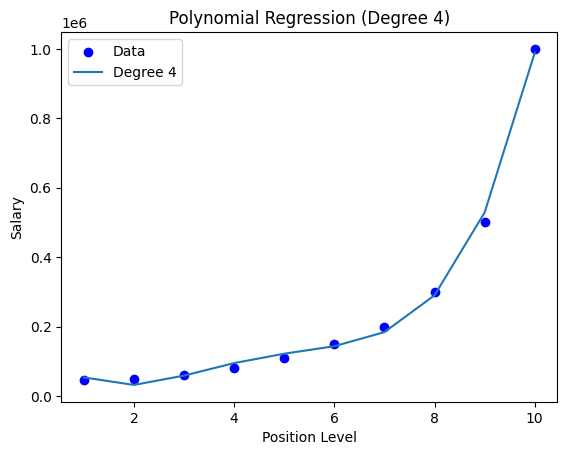

Degree 4 → R²: 0.9974, RMSE: 14503.23


In [6]:
for degree in [2, 3, 4]:
    poly = PolynomialFeatures(degree=degree)
    X_poly = poly.fit_transform(X)

    poly_model = LinearRegression()
    poly_model.fit(X_poly, y)
    y_poly_pred = poly_model.predict(X_poly)

    plt.scatter(X, y, color="blue", label="Data")
    plt.plot(X, y_poly_pred, label=f"Degree {degree}")
    plt.title(f"Polynomial Regression (Degree {degree})")
    plt.xlabel("Position Level")
    plt.ylabel("Salary")
    plt.legend()
    plt.show()

    r2   = r2_score(y, y_poly_pred)
    rmse = np.sqrt(mean_squared_error(y, y_poly_pred))
    print(f"Degree {degree} → R²: {r2:.4f}, RMSE: {rmse:.2f}")

In [7]:
results = []

# Linear
results.append({
    "Model": "Linear",
    "R2": r2_score(y, lin_model.predict(X)),
    "RMSE": np.sqrt(mean_squared_error(y, lin_model.predict(X)))
})

# Polynomial degrees 2 to 4
for degree in [2, 3, 4]:
    poly = PolynomialFeatures(degree=degree)
    X_poly = poly.fit_transform(X)
    pm = LinearRegression().fit(X_poly, y)
    results.append({
        "Model": f"Poly Degree {degree}",
        "R2": r2_score(y, pm.predict(X_poly)),
        "RMSE": np.sqrt(mean_squared_error(y, pm.predict(X_poly)))
    })

print(pd.DataFrame(results).to_string(index=False))

        Model       R2          RMSE
       Linear 0.669041 163388.735193
Poly Degree 2 0.916208  82212.124005
Poly Degree 3 0.981210  38931.504012
Poly Degree 4 0.997392  14503.234910


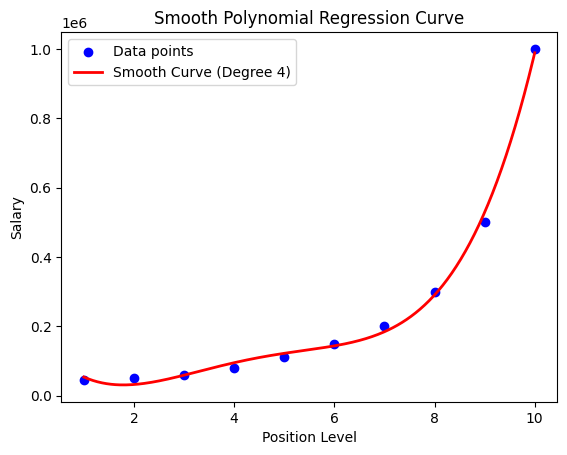

In [8]:
X_smooth = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)

poly4 = PolynomialFeatures(degree=4)
X_smooth_poly = poly4.fit_transform(X_smooth)

pm4 = LinearRegression()
pm4.fit(poly4.fit_transform(X), y)
y_smooth = pm4.predict(X_smooth_poly)

plt.scatter(X, y, color="blue", label="Data points")
plt.plot(X_smooth, y_smooth, color="red", linewidth=2, label="Smooth Curve (Degree 4)")
plt.title("Smooth Polynomial Regression Curve")
plt.xlabel("Position Level")
plt.ylabel("Salary")
plt.legend()
plt.show()

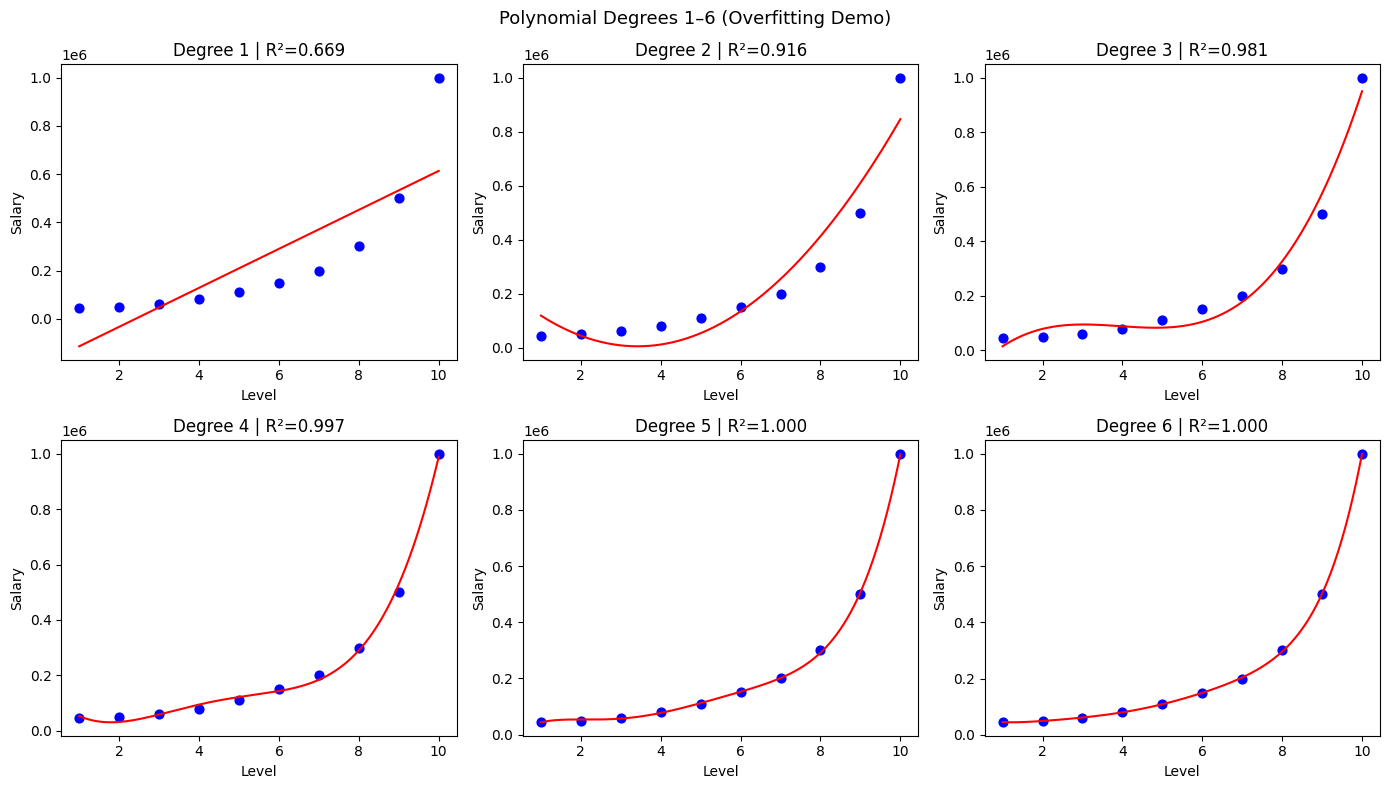

In [9]:
X_smooth = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)

plt.figure(figsize=(14, 8))
for i, degree in enumerate([1, 2, 3, 4, 5, 6], 1):
    poly = PolynomialFeatures(degree=degree)
    pm = LinearRegression().fit(poly.fit_transform(X), y)
    y_s = pm.predict(poly.fit_transform(X_smooth))

    plt.subplot(2, 3, i)
    plt.scatter(X, y, color="blue", s=40)
    plt.plot(X_smooth, y_s, color="red")
    plt.title(f"Degree {degree} | R²={r2_score(y, pm.predict(poly.fit_transform(X))):.3f}")
    plt.xlabel("Level")
    plt.ylabel("Salary")

plt.suptitle("Polynomial Degrees 1–6 (Overfitting Demo)", fontsize=13)
plt.tight_layout()
plt.show()